# CS2 — Atlantic hurricane (Ida-like), August–September 2021

Companion notebook for the *Computers & Geosciences* paper *An Open Python Framework for Reproducible Multi-Source Ocean Data Integration*. It loads the Zarr output produced by the offline fixture pipeline (`tests/fixtures/cs2_offline.yaml`) and reproduces the figures used in the Results section.

**Reproducibility contract.** Re-running this notebook from a fresh checkout regenerates the identical content hash printed in the final section. The pipeline is declarative (YAML) and the data sources are deterministic Gulf-of-Mexico-shaped fixtures that ship with the repository, so no external credentials are required.

**Scope note.** The bundled IBTrACS-style storm track is a synthetic, Ida-like CSV used only to overlay the storm path on the figures below for visual context — it is not a pipeline source and does not enter the harmonized dataset or the `mosaic:content_hash`.

## 1. Bootstrap — run the pipeline if its output is missing

In [19]:
from __future__ import annotations

import json
import os
from pathlib import Path

# Resolve the repository root regardless of where the notebook is launched.
NB_DIR = Path.cwd()
if NB_DIR.name == 'notebooks':
    REPO_ROOT = NB_DIR.parent
else:
    REPO_ROOT = NB_DIR
os.chdir(REPO_ROOT)

PIPELINE  = Path('tests/fixtures/cs2_offline.yaml')
OUTPUT    = Path('out/cs2_atlantic_hurricane_offline.zarr')
SIDECAR   = OUTPUT.with_suffix(OUTPUT.suffix + '.stac.json')
TRACK_CSV = Path('tests/fixtures/cs2/ibtracs_ida_like.csv')

if not OUTPUT.exists():
    # Build synthetic fixtures (deterministic) and run the pipeline.
    from tests.fixtures.build_cs2_fixtures import build_all
    build_all(REPO_ROOT / 'tests' / 'fixtures' / 'cs2')
    import mosaic as ms
    ms.run(str(PIPELINE))

print(f'output: {OUTPUT} ({OUTPUT.exists()})')
print(f'sidecar: {SIDECAR} ({SIDECAR.exists()})')
print(f'track: {TRACK_CSV} ({TRACK_CSV.exists()})')

output: out\cs2_atlantic_hurricane_offline.zarr (True)
sidecar: out\cs2_atlantic_hurricane_offline.zarr.stac.json (True)
track: tests\fixtures\cs2\ibtracs_ida_like.csv (True)


## 2. Load the integrated dataset, its provenance sidecar, and the storm track

In [20]:
import pandas as pd
import xarray as xr

ds = xr.open_zarr(OUTPUT, consolidated=True)
with open(SIDECAR) as fh:
    stac = json.load(fh)
track = pd.read_csv(TRACK_CSV, parse_dates=['ISO_TIME'])

print(ds)

<xarray.Dataset> Size: 244kB
Dimensions:                         (time: 8, latitude: 29, longitude: 35)
Coordinates:
  * time                            (time) datetime64[ns] 64B 2021-08-26 ... ...
  * latitude                        (latitude) float32 116B 18.0 18.5 ... 32.0
  * longitude                       (longitude) float32 140B -95.0 ... -78.0
Data variables:
    air_pressure_at_mean_sea_level  (time, latitude, longitude) float32 32kB ...
    eastward_wind                   (time, latitude, longitude) float32 32kB ...
    hurricane_zone                  (time, latitude, longitude) bool 8kB ...
    northward_wind                  (time, latitude, longitude) float32 32kB ...
    precipitation_amount            (time, latitude, longitude) float32 32kB ...
    sea_surface_temperature         (time, latitude, longitude) float32 32kB ...
    sea_surface_temperature_qc      (time, latitude, longitude) int8 8kB ...
    storm_intensity                 (time, latitude, longitude) float32

In [21]:
props = stac['properties']
summary = {
    'pipeline_hash': props['mosaic:pipeline_hash'],
    'content_hash':  props['mosaic:content_hash'],
    'sources':       [s['source_id'] for s in props['mosaic:inputs']],
    'mapping_accuracy': props['mosaic:harmonization']['mapping_accuracy'],
    'derived_variables': props['mosaic:harmonization']['derived']['derived'],
}
summary

{'pipeline_hash': 'blake3:34e9eb86271138849113418be31a4b6d9fa8f3e03e158245ff82fdb4d08b28f4',
 'content_hash': 'blake3:1cb91093a7448bc7bde9e27516516a56feacee71f40f1429bce481cc695cf295',
 'sources': ['cmems_sst', 'era5_atmos'],
 'mapping_accuracy': 1.0,
 'derived_variables': ['wind_speed', 'storm_intensity', 'hurricane_zone']}

## 3. Mean sea-level pressure and wind evolution

Four-panel snapshot of `air_pressure_at_mean_sea_level` with 10 m wind vectors and the storm track overlaid, across the Ida-like landfall window (26 Aug — 2 Sep 2021).

In [22]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({'figure.dpi': 110, 'font.size': 9})

n = ds.sizes['time']
panel_days = np.linspace(0, n - 1, 4, dtype=int)
panel_days

array([0, 2, 4, 7])

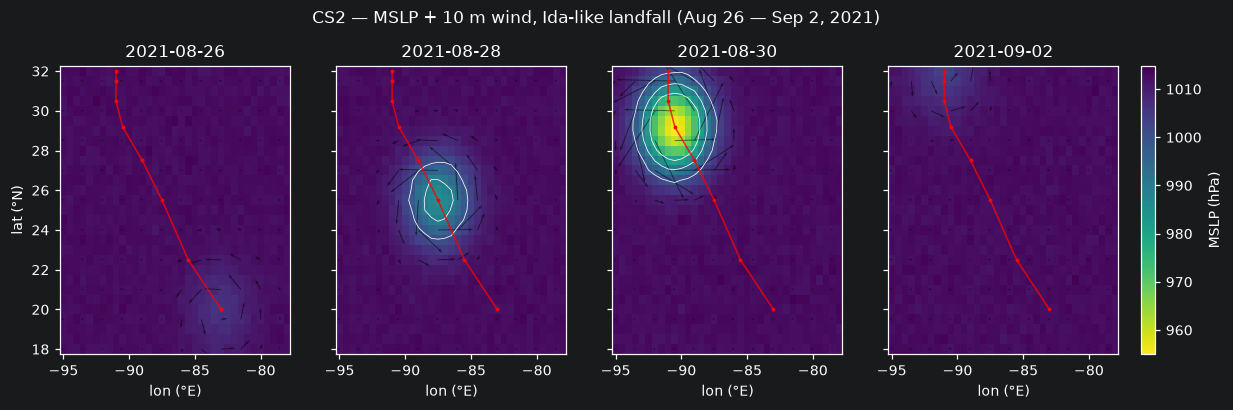

In [23]:
fig, axes = plt.subplots(1, 4, figsize=(13, 3.4), sharey=True)
pmin = float(ds['air_pressure_at_mean_sea_level'].min())
pmax = float(ds['air_pressure_at_mean_sea_level'].max())
step = 3
for ax, t in zip(axes, panel_days):
    p = ds['air_pressure_at_mean_sea_level'].isel(time=t)
    u = ds['eastward_wind'].isel(time=t)
    v = ds['northward_wind'].isel(time=t)
    ax.pcolormesh(
        p.longitude, p.latitude, p.values, cmap='viridis_r',
        vmin=pmin, vmax=pmax, shading='auto',
    )
    ax.contour(p.longitude, p.latitude, p.values, levels=[980, 990, 1000], colors='white', linewidths=0.5)
    ax.quiver(
        u.longitude[::step], u.latitude[::step],
        u.values[::step, ::step], v.values[::step, ::step],
        scale=300, color='k', alpha=0.55, width=0.004,
    )
    ax.plot(track['LON'], track['LAT'], 'r-', lw=1.0, alpha=0.8)
    ax.plot(track['LON'], track['LAT'], 'r.', ms=3)
    ax.set_title(pd.to_datetime(ds['time'].isel(time=t).values).strftime('%Y-%m-%d'))
    ax.set_xlabel('lon (°E)')
axes[0].set_ylabel('lat (°N)')
sm = plt.cm.ScalarMappable(norm=plt.Normalize(vmin=pmin, vmax=pmax), cmap='viridis_r')
fig.colorbar(sm, ax=axes, fraction=0.025, pad=0.02, label='MSLP (hPa)')
fig.suptitle('CS2 — MSLP + 10 m wind, Ida-like landfall (Aug 26 — Sep 2, 2021)', y=1.03)
plt.show()

## 4. SST cold wake

`sea_surface_temperature` harmonised from CMEMS Global L4 SST (`analysed_sst`), showing the cold wake left by the storm along its track.

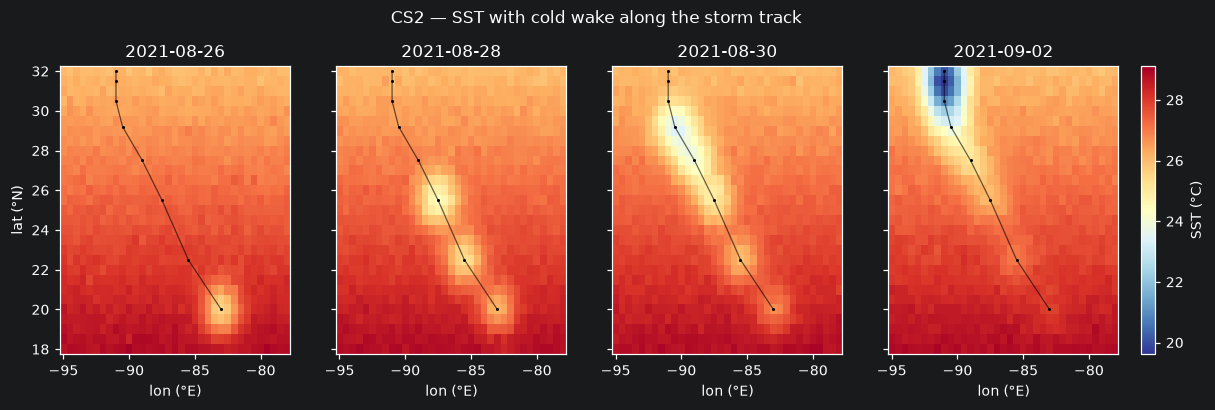

In [24]:
fig, axes = plt.subplots(1, 4, figsize=(13, 3.4), sharey=True)
sst_k = ds['sea_surface_temperature']
vmin, vmax = float(sst_k.min()) - 273.15, float(sst_k.max()) - 273.15
for ax, t in zip(axes, panel_days):
    ax.pcolormesh(
        sst_k.longitude, sst_k.latitude, sst_k.isel(time=t).values - 273.15,
        cmap='RdYlBu_r', vmin=vmin, vmax=vmax, shading='auto',
    )
    ax.plot(track['LON'], track['LAT'], 'k-', lw=0.8, alpha=0.6)
    ax.plot(track['LON'], track['LAT'], 'k.', ms=2)
    ax.set_title(pd.to_datetime(ds['time'].isel(time=t).values).strftime('%Y-%m-%d'))
    ax.set_xlabel('lon (°E)')
axes[0].set_ylabel('lat (°N)')
sm = plt.cm.ScalarMappable(norm=plt.Normalize(vmin=vmin, vmax=vmax), cmap='RdYlBu_r')
fig.colorbar(sm, ax=axes, fraction=0.025, pad=0.02, label='SST (°C)')
fig.suptitle('CS2 — SST with cold wake along the storm track', y=1.03)
plt.show()

## 5. Hurricane-zone mask

`hurricane_zone = (wind_speed > 17 m s⁻¹) & (air_pressure_at_mean_sea_level < 980 hPa)` — a derived variable combining the harmonised wind and pressure fields.

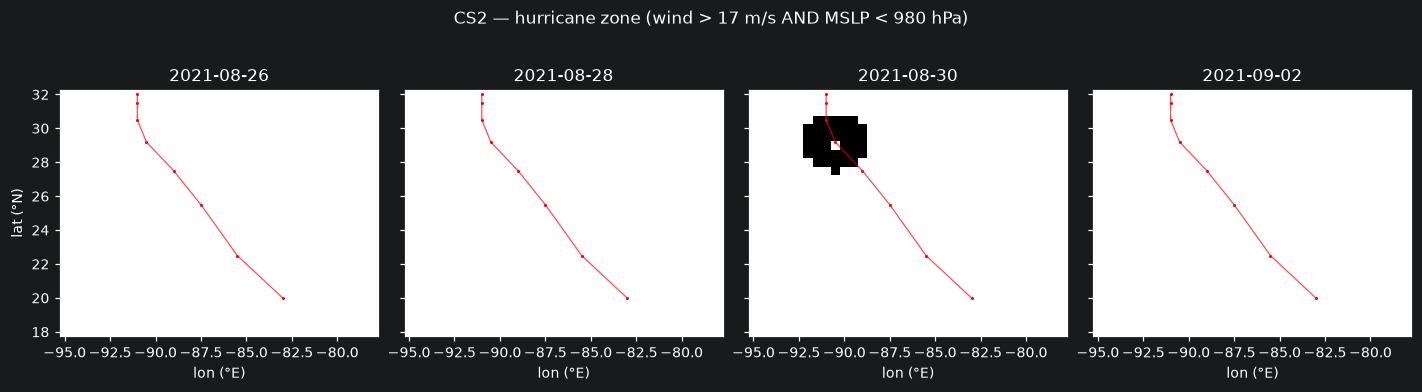

hurricane-zone cells flagged (full window): 78


In [25]:
fig, axes = plt.subplots(1, 4, figsize=(13, 3.4), sharey=True)
for ax, t in zip(axes, panel_days):
    m = ds['hurricane_zone'].isel(time=t).astype('uint8')
    ax.pcolormesh(m.longitude, m.latitude, m.values, cmap='Greys', vmin=0, vmax=1, shading='auto')
    ax.plot(track['LON'], track['LAT'], 'r-', lw=0.8, alpha=0.7)
    ax.plot(track['LON'], track['LAT'], 'r.', ms=2)
    ax.set_title(pd.to_datetime(ds['time'].isel(time=t).values).strftime('%Y-%m-%d'))
    ax.set_xlabel('lon (°E)')
axes[0].set_ylabel('lat (°N)')
fig.suptitle('CS2 — hurricane zone (wind > 17 m/s AND MSLP < 980 hPa)', y=1.03)
plt.tight_layout()
plt.show()

print(f"hurricane-zone cells flagged (full window): "
      f"{int(ds['hurricane_zone'].astype('uint8').sum().values)}")

## 6. Storm intensity and hurricane-zone footprint over time

`storm_intensity = 1013.0 - air_pressure_at_mean_sea_level`, plotted against the daily count of `hurricane_zone` cells.

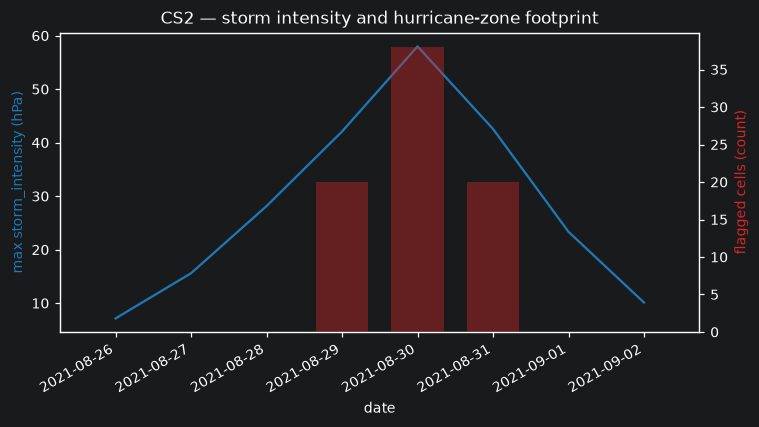

In [26]:
intensity_max = ds['storm_intensity'].max(dim=('latitude', 'longitude'))
flagged_per_day = ds['hurricane_zone'].astype('uint8').sum(dim=('latitude', 'longitude'))

fig, ax = plt.subplots(figsize=(7.5, 4.0))
ax.plot(intensity_max.time, intensity_max.values, color='tab:blue',
        label='max storm_intensity (hPa)')
ax2 = ax.twinx()
ax2.bar(flagged_per_day.time, flagged_per_day.values,
        color='tab:red', alpha=0.4, width=0.7,
        label='flagged cells')
ax.set_xlabel('date')
ax.set_ylabel('max storm_intensity (hPa)', color='tab:blue')
ax2.set_ylabel('flagged cells (count)', color='tab:red')
ax.set_title('CS2 — storm intensity and hurricane-zone footprint')
fig.autofmt_xdate()
plt.show()

## 7. Provenance — content addressing of the result

Every MOSAIC run emits a STAC sidecar that pins the exact pipeline and the bit-exact output. The hashes below should match across machines and Python versions when the fixture-based pipeline is used.

In [27]:
for k in ('mosaic:pipeline_hash', 'mosaic:content_hash'):
    print(f'{k:<25} {props[k]}')

print()
print('inputs:')
for inp in props['mosaic:inputs']:
    print(f"  - {inp['source_id']:<10} {inp['plugin']:<14} {inp.get('uri', '')}")

print()
print('derived:')
for d in props['mosaic:harmonization']['derived']['derived']:
    print(f'  + {d}')

mosaic:pipeline_hash      blake3:34e9eb86271138849113418be31a4b6d9fa8f3e03e158245ff82fdb4d08b28f4
mosaic:content_hash       blake3:1cb91093a7448bc7bde9e27516516a56feacee71f40f1429bce481cc695cf295

inputs:
  - cmems_sst  local_netcdf   
  - era5_atmos local_netcdf   

derived:
  + wind_speed
  + storm_intensity
  + hurricane_zone


---
*Notebook generated by `notebooks/_build_cs2_notebook.py`. Do not edit by hand — regenerate from the script to keep the build auditable.*